<a href="https://colab.research.google.com/github/AliSalman25/first-Jupyter-Notebook-for-the-experiments/blob/main/first_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Date Source** : OPEC formal website    
            https://www.opec.org/opec-basket-price.html

**Type of data** : OPEC Reference Basket (ORB)  
Period : 2003-01-02 to 2025-06-27

**Framing** :  Univariate

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv'
df = pd.read_csv(file_path)
df.head()


,Date,Price
0,2003-01-02,30.05
1,2003-01-03,30.83
2,2003-01-06,30.71
3,2003-01-07,29.72
4,2003-01-08,28.86


**Data Preparation**

Step 1:  Xml file Oil price data  downloaded from the official OPEC website , after that converted it to CSV in colab



In [ ]:
import pandas as pd
import xml.etree.ElementTree as ET
from google.colab import drive

#  conn Google Drive
drive.mount('/content/drive')

#  path  XML
xml_file_path = '/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/basketDayArchives.xml'

#  read XML
tree = ET.parse(xml_file_path)
root = tree.getroot()

# data and price from xml fil
dates = []
prices = []
for basket in root.findall('{http://tempuri.org/basketDayArchives.xsd}BasketList'):
    date = basket.attrib['data']
    price = float(basket.attrib['val'])
    dates.append(date)
    prices.append(price)

#  create DataFrame
df = pd.DataFrame({
    'Date': pd.to_datetime(dates),
    'Price': prices
})

#     save to CSV
csv_file_path = '/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv'
df.to_csv(csv_file_path, index=False)

#    read first 5 columns
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Date,Price
0,2003-01-02,30.05
1,2003-01-03,30.83
2,2003-01-06,30.71
3,2003-01-07,29.72
4,2003-01-08,28.86


**Data Preparation**

Step 2: Code for Exploratory Data Analysis (EDA)

- They display general information about the data, including the number of rows and columns.

- They check if there are any missing (null) values.

- They provide statistics about the Price column.

- They ensure that the Date column is stored correctly as a datetime type.

- They detect if there are any duplicate dates.

In [ ]:
import pandas as pd

#  Read the CSV file
file_path = '/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv'
df = pd.read_csv(file_path)

#  Display general information about the data
print("Data shape (rows, columns):", df.shape)
print("\nGeneral information and missing data:")
print(df.info())

#  Display the first 5 rows
print("\nFirst 5 records:")
print(df.head())

#  Check  missing data in columns
print("\nNumber of missing values per column:")
print(df.isnull().sum())

#  Descriptive statistics for the 'Price' column
print("\nDescriptive statistics for the 'Price' column:")
print(df['Price'].describe())

#  Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])
print("\n'Date' column data type after conversion:")
print(df['Date'].dtype)

#  Check for duplicate dates (optional)
duplicates = df['Date'].duplicated().sum()
print(f"\nNumber of duplicated dates: {duplicates}")


Data shape (rows, columns): (5799, 2)

General information and missing data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5799 entries, 0 to 5798
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5799 non-null   object 
 1   Price   5799 non-null   float64
dtypes: float64(1), object(1)
memory usage: 90.7+ KB
None

First 5 records:
         Date  Price
0  2003-01-02  30.05
1  2003-01-03  30.83
2  2003-01-06  30.71
3  2003-01-07  29.72
4  2003-01-08  28.86

Number of missing values per column:
Date     0
Price    0
dtype: int64

Descriptive statistics for the 'Price' column:
count    5799.000000
mean       70.377513
std        25.693673
min        12.220000
25%        50.695000
50%        68.680000
75%        88.445000
max       140.730000
Name: Price, dtype: float64

'Date' column data type after conversion:
datetime64[ns]

Number of duplicated dates: 0


**# Manual ARIMA Model**

We implemented a manual ARIMA (AutoRegressive Integrated Moving Average) model to forecast daily crude oil prices using the historical OPEC dataset.

arima(p d q)

import library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error


download dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


# **Check the Stationarity using ADF**

A stationary time series is one whose statistical properties—such as mean, variance, and autocorrelation—do not change over time. This stability is important because many time series forecasting models, including ARIMA, assume stationarity to make accurate predictions.

*   If a series is ***stationary***, it means the data fluctuate around a constant mean and variance over time.
*   If ***not stationary***, the series might have trends, seasonality, or changing variance, which complicates modeling.


# To check stationarity with ADF test:
1. ADF Statistic tests the null hypothesis that the time series has a unit root .
2.   **If p-value ≤ 0.05**, you reject the null hypothesis: series is stationary.
3. **If p-value > 0.05**, you fail to reject the null  series is non-stationary : differencing is needed.



In [ ]:
result = adfuller(df['Price'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
for key, value in result[4].items():
    print('Critical Values:')
    print(f'   {key}, {value}')


ADF Statistic: -2.969114
p-value: 0.037881
Critical Values:
   1%, -3.4314846190761017
Critical Values:
   5%, -2.862041393601955
Critical Values:
   10%, -2.5670368899004763


# Accodrding to the result

ADF Statistic: -2.969114

p-value: 0.037881

Critical Values:
   1%, -3.4314846190761017

Critical Values:
   5%, -2.862041393601955

Critical Values:
   10%, -2.5670368899004763


---



The ADF statistic (-2.9691) is less than the 5% critical value (-2.8620), so you reject the null hypothesis of non-stationarity at the 5% significance level.

The p-value (0.0379) is less than 0.05, confirming stationarity at 5% level.

However, the ADF statistic is greater than the 1% critical value (-3.4315), so you cannot reject non-stationarity at the 1% level (which is stricter).

Conclusion:
Your time series is stationary at the 5% significance level, meaning you can proceed with modeling without differencing, or at most with minimal differencing. But depending on modeling results, differencing could still be applied if needed.

We can use d = 0


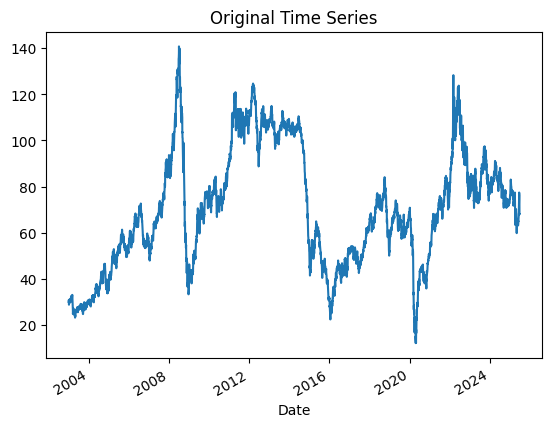

In [ ]:
df['Price'].plot(title='Original Time Series')
plt.show()


# PACF and ACF

First: Divide the data into training and testing.

In [ ]:
# The test days ( the last 30 days)
test_size = 30

# Divide the data
train = df['Price'][:-test_size]
test = df['Price'][-test_size:]

print(f"Training size: {len(train)}")
print(f"Testing size: {len(test)}")


Training size: 5769
Testing size: 30


# **Dr . alvaro**
# ***i need your recomandation for this code***
# how days i will use 30 days or more or less than?

> Add blockquote



below the code for PACF and ACF to get the equation for arima, but just i need to know days previously used (the code below building on 30 day we can change it)
Training	5769 rows
Testing	30 rows

<Figure size 1400x600 with 0 Axes>

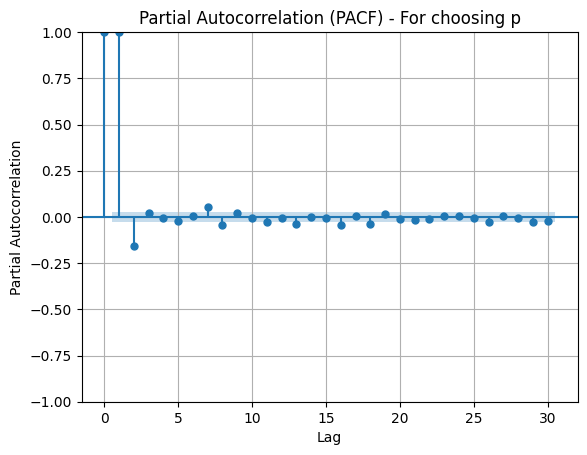

<Figure size 1400x600 with 0 Axes>

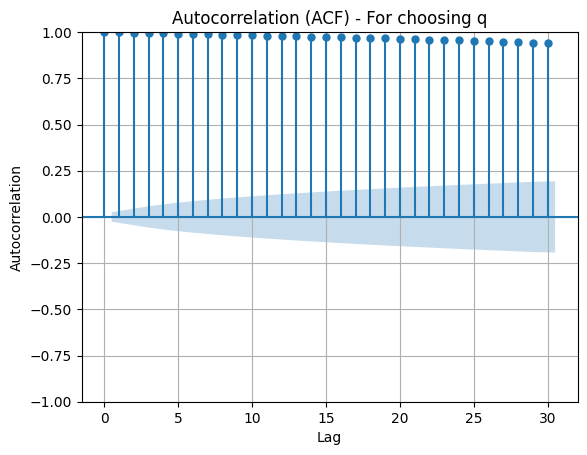

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# this block for PACF plot  p
plt.figure(figsize=(14, 6))
plot_pacf(train, lags=30)
plt.title("Partial Autocorrelation (PACF) - For choosing p")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.grid(True)
plt.show()

# this is for ACF plot  q
plt.figure(figsize=(14, 6))
plot_acf(train, lags=30)
plt.title("Autocorrelation (ACF) - For choosing q")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()


PACF :
There is a clear at lag = 1 (the first bar is very large).
After lag 1, the values drop , approach zero, and do not exceed the confidence bounds (blue shading).
This indicates a strong effect only at lag 1.
Therefore, p = 1 (the number of AR terms = 1).

ACF :
The bars are almost all high and stable near 1 up to lag = 30, and it gradually decreases.
Therefore, q = 0.

Based on the analytic the model can be ARIMA(1,0,0)
all data 100%

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 5799
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -9320.073
Date:                Mon, 14 Jul 2025   AIC                          18646.146
Time:                        21:35:36   BIC                          18666.143
Sample:                             0   HQIC                         18653.102
                               - 5799                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.4412     11.671      5.950      0.000      46.567      92.315
ar.L1          0.9990      0.001   1986.995      0.000       0.998       1.000
sigma2         1.4556      0.011    134.928      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


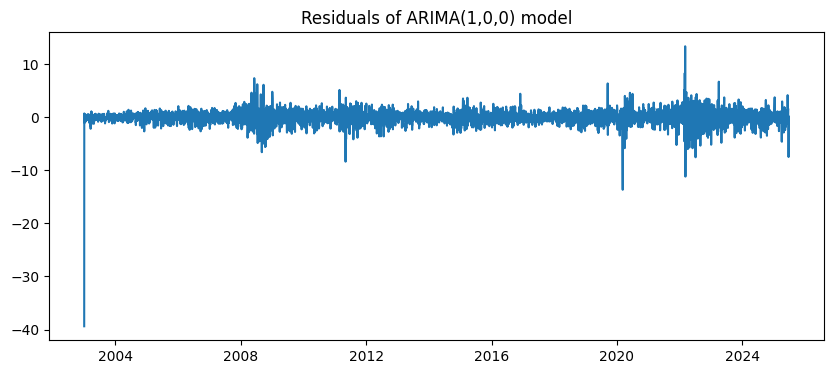

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# DataFrame
series = df['Price'].dropna()

# excute ARIMA(1,0,0)
model = ARIMA(series, order=(1,0,0))

# trsining
model_fit = model.fit()

print(model_fit.summary())

# forcasting next 10 days
forecast = model_fit.forecast(steps=10)
print("Forecasted values:\n", forecast)

#  Residuals
residuals = model_fit.resid
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title('Residuals of ARIMA(1,0,0) model')
plt.show()




Residual=Actual Value−Predicted Value

Based on the analytic the model can be ARIMA(1,0,0) divide data 70% train and 30% test

Training size: 5769
Testing size: 30


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

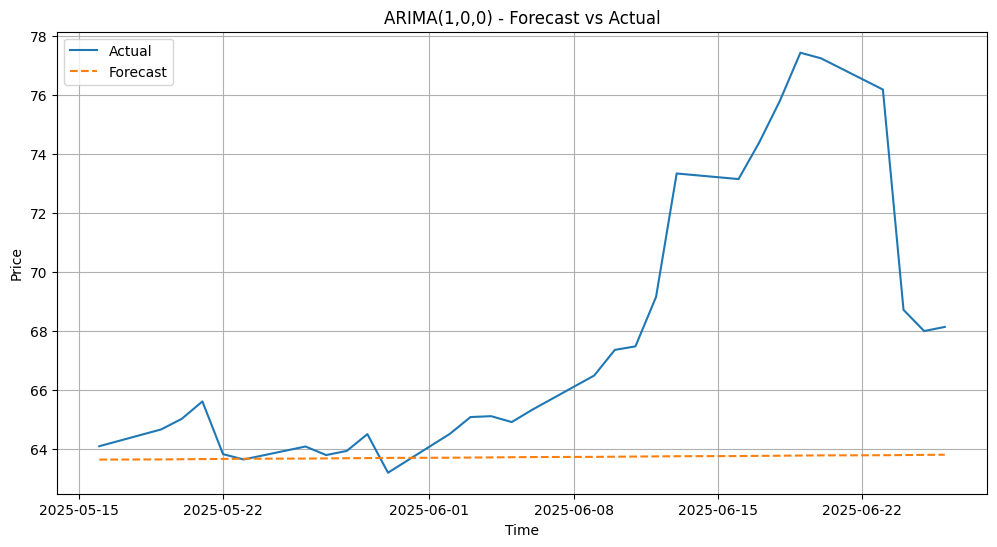

Root Mean Squared Error (RMSE): 6.0645


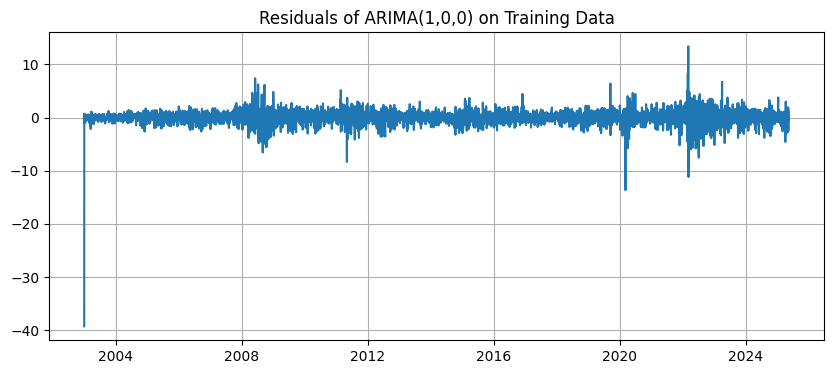

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np


#  df on Price
series = df['Price'].dropna()

# div data to train and test
test_size = 30
train = series[:-test_size]
test = series[-test_size:]

print(f"Training size: {len(train)}")
print(f"Testing size: {len(test)}")

# excute arima model
model = ARIMA(train, order=(1, 0, 0))
model_fit = model.fit()


#  التنبؤ بعدد نقاط مساوية للاختبار Predict the same number of points to the test

forecast = model_fit.forecast(steps=test_size)

# result plot
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast', linestyle='--')
plt.title('ARIMA(1,0,0) - Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


# rmsa calculating

rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


# the code of residuals
residuals = model_fit.resid

plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title('Residuals of ARIMA(1,0,0) on Training Data')
plt.grid(True)
plt.show()


div 80/20

Training size: 4639
Testing size: 1160


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -6913.487
Date:                Mon, 14 Jul 2025   AIC                          13832.975
Time:                        21:28:04   BIC                          13852.301
Sample:                             0   HQIC                         13839.774
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4876     11.823      5.708      0.000      44.315      90.660
ar.L1          0.9991      0.000   2062.902      0.000       0.998       1.000
sigma2         1.1518      0.010    115.447      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


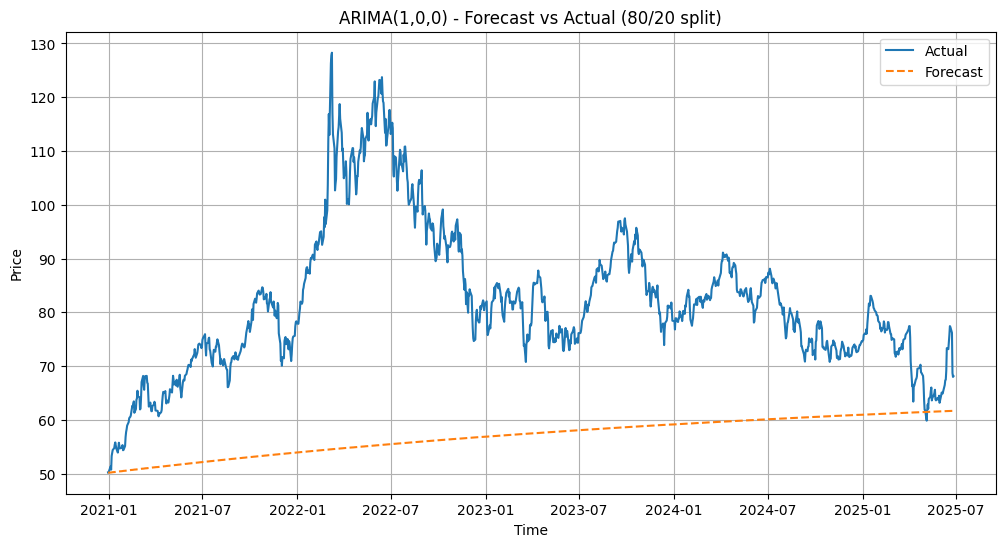

Root Mean Squared Error (RMSE): 28.5601


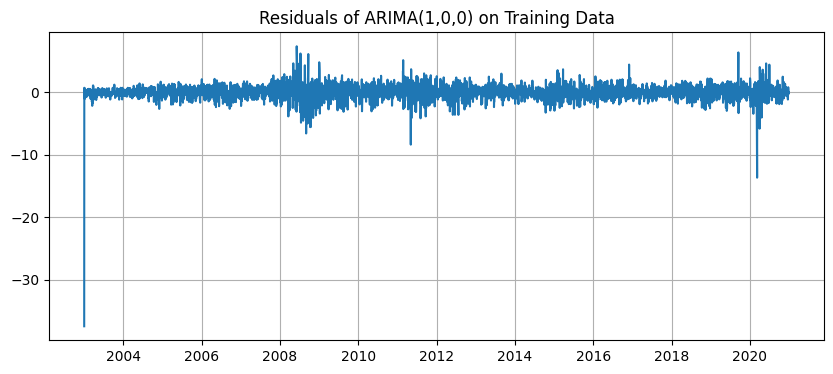

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

# drop nan
series = df['Price'].dropna()

# div to train 80 test 20
split_index = int(len(series) * 0.8)
train = series[:split_index]
test = series[split_index:]

print(f"Training size: {len(train)}")
print(f"Testing size: {len(test)}")

# ARIMA(1,0,0)on training data 80%
model = ARIMA(train, order=(1,0,0))
model_fit = model.fit()


print(model_fit.summary())

# forcasting on 20%
forecast = model_fit.forecast(steps=len(test))
print("Forecasted values:\n", forecast)

# plot actual data and forcasting data
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast', linestyle='--')
plt.title('ARIMA(1,0,0) - Forecast vs Actual (80/20 split)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

#  RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# residuals
residuals = model_fit.resid
plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title('Residuals of ARIMA(1,0,0) on Training Data')
plt.grid(True)
plt.show()


Evaluate ARIMA (MAE, RMSE)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


MAE (Mean Absolute Error): 24.9789
RMSE (Root Mean Squared Error): 28.5601


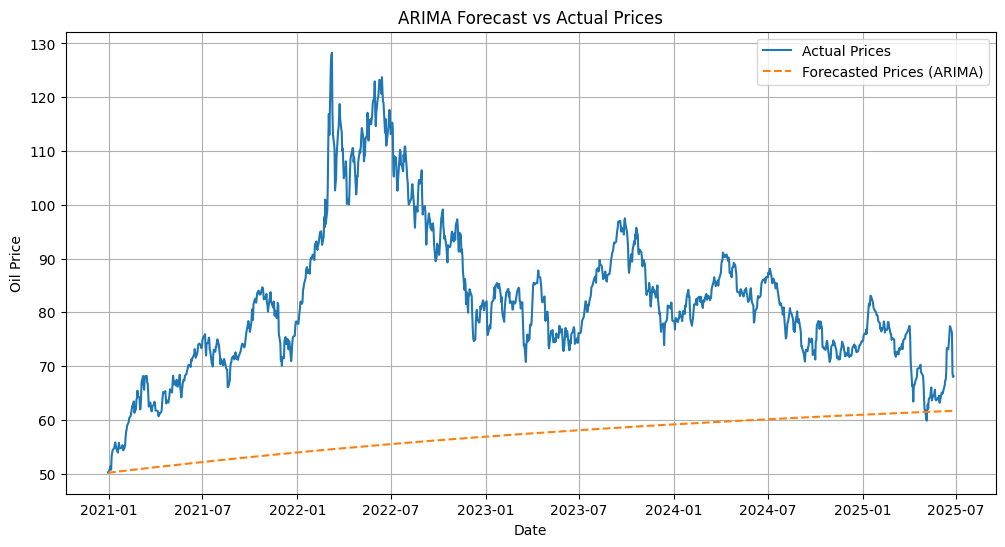

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# the predictions
forecast = model_fit.forecast(steps=len(test))

#  evaluation
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")

# plot the carve
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual Prices')
plt.plot(test.index, forecast, label='Forecasted Prices (ARIMA)', linestyle='--')
plt.title("ARIMA Forecast vs Actual Prices")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True)
plt.show()




---
Auto ARIMA


---




In [2]:
!pip uninstall -y u8darts statsforecast pmdarima
!pip install statsforecast>=1.4 pmdarima


Found existing installation: u8darts 0.31.0
Uninstalling u8darts-0.31.0:
  Successfully uninstalled u8darts-0.31.0
Found existing installation: pmdarima 2.0.4
Uninstalling pmdarima-2.0.4:
  Successfully uninstalled pmdarima-2.0.4


In [3]:
!pip install statsforecast>=1.4 pmdarima


In [2]:
!pip install sktime[all_extras]


  Using cached sktime-0.38.4-py3-none-any.whl.metadata (35 kB)
  Using cached skforecast-0.14.0-py3-none-any.whl.metadata (16 kB)
  Using cached u8darts-0.31.0-py3-none-any.whl.metadata (53 kB)
  Using cached scipy-1.15.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached skforecast-0.14.0-py3-none-any.whl (692 kB)
Using cached scipy-1.15.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
Using cached u8darts-0.31.0-py3-none-any.whl (934 kB)
Using cached sktime-0.38.4-py3-none-any.whl (35.5 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.10.1
    Uninstalling scipy-1.10.1:
      Successfully uninstalled scipy-1.10.1


In [28]:
from pmdarima import auto_arima
from sktime.forecasting.statsforecast import StatsForecastAutoARIMA
from sktime.forecasting.base import ForecastingHorizon
import pandas as pd

print("Libraries imported successfully!")


Libraries imported successfully!


In [59]:
import pandas as pd

# تحميل البيانات
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv')

# تحويل العمود التاريخي إلى نوع datetime وضبطه كفهرس زمني
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# التحقق من وجود قيم مفقودة في عمود السعر وإزالتها أو معالجتها
df = df.dropna(subset=['Price'])


In [60]:
# تقسيم البيانات
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f"Training data points: {len(train)}")
print(f"Testing data points: {len(test)}")

# تطبيق Auto ARIMA على بيانات التدريب فقط
from pmdarima import auto_arima

auto_model = auto_arima(train['Price'],
                        seasonal=False,
                        stepwise=True,
                        random_state=42,
                        suppress_warnings=True,
                        error_action='ignore')

# طباعة ملخص النموذج
print(auto_model.summary())


Training data points: 4639
Testing data points: 1160


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4639
Model:               SARIMAX(5, 1, 5)   Log Likelihood               -6742.742
Date:                Fri, 25 Jul 2025   AIC                          13507.484
Time:                        21:26:19   BIC                          13578.347
Sample:                             0   HQIC                         13532.415
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1594      0.195     -5.933      0.000      -1.542      -0.776
ar.L2          0.1246      0.159      0.785      0.433      -0.187       0.436
ar.L3          0.9904      0.128      7.750      0.0

In [61]:
n_periods = len(test)
forecast = auto_model.predict(n_periods=n_periods)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [63]:
# إنشاء فهرس التواريخ من مجموعة الاختبار
forecast_index = test.index

# إنشاء DataFrame للتوقعات
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=['Forecast'])


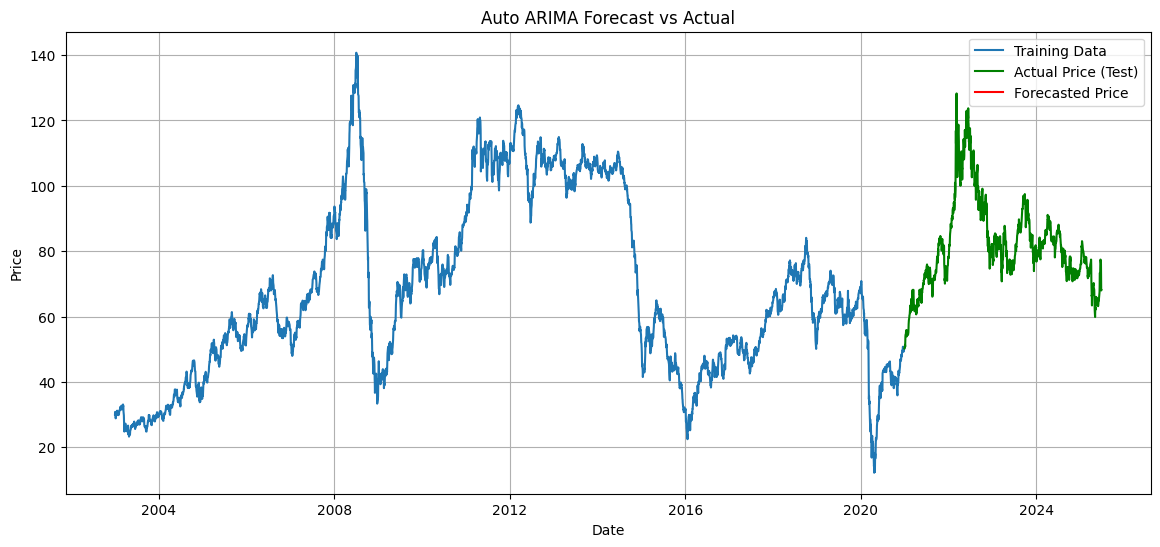

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(train['Price'], label='Training Data')
plt.plot(test['Price'], label='Actual Price (Test)', color='green')
plt.plot(forecast_df['Forecast'], label='Forecasted Price', color='red')
plt.title('Auto ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")


MAE: 29.72874592514859
RMSE: 32.662924072322326


Manual ARIMA vs Auto ARIMA


---
Model =	MAE  =	RMSE

ARIMA(1,0,0)  =   24.98    =	28.56

Auto ARIMA=  29.73=  32.66


